In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv("/Users/jussaragaspar/Downloads/Final project/time_series_60min_singleindex_filtered.csv")

# Convert timestamp
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
df = df.set_index("utc_timestamp")
df.dropna(inplace=True)



===== FR_load_actual_entsoe_transparency =====
Baseline MAE: 1816.39, RMSE: 2329.82
Recursive MAE: 8873.62, RMSE: 10788.51


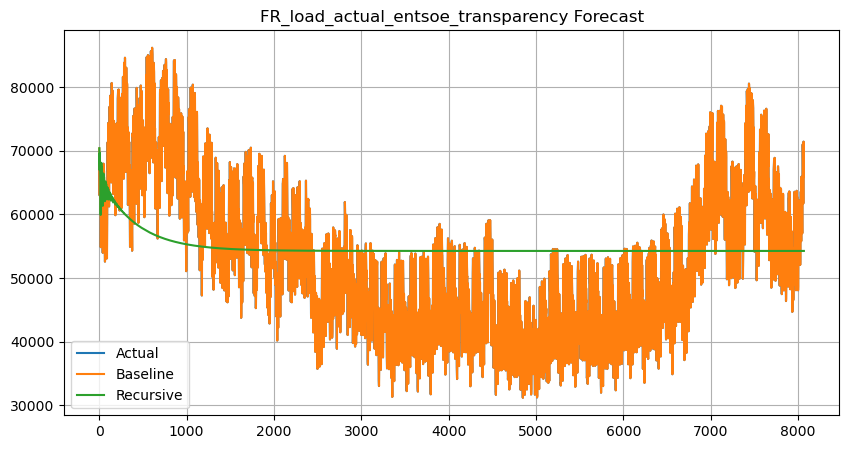


===== DE_load_actual_entsoe_transparency =====
Baseline MAE: 1993.31, RMSE: 2812.58
Recursive MAE: 8643.51, RMSE: 9933.75


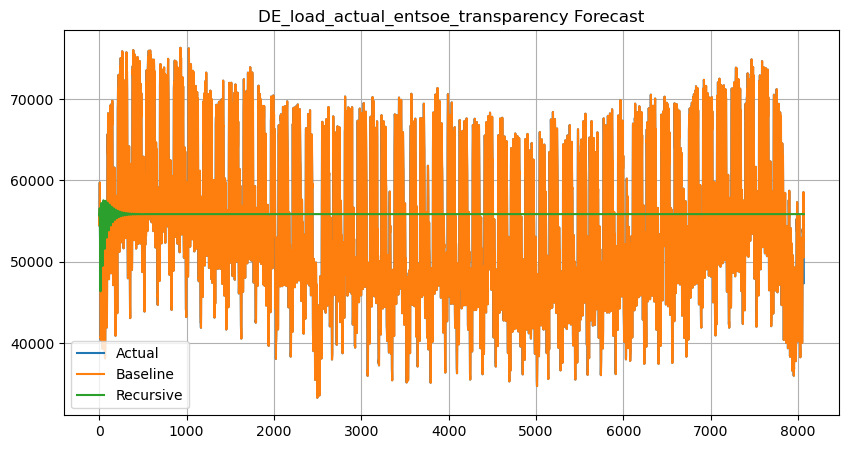


===== BE_load_actual_entsoe_transparency =====
Baseline MAE: 285.74, RMSE: 390.80
Recursive MAE: 1130.31, RMSE: 1370.27


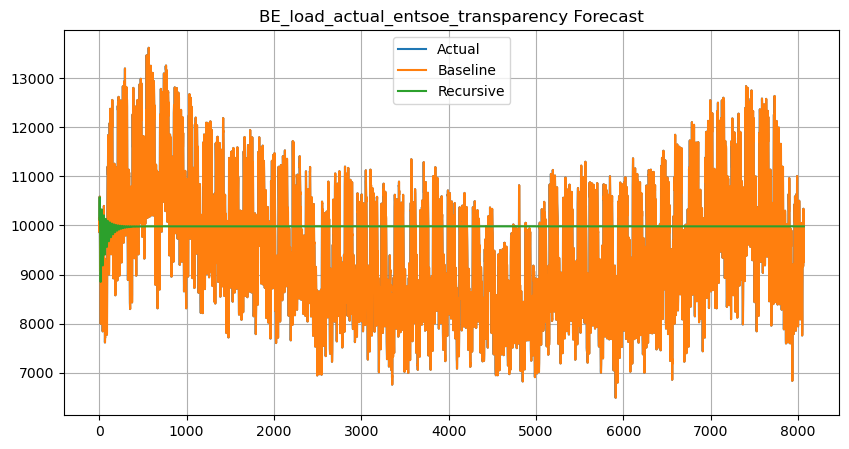

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

n_lags = 24
countries =["FR_load_actual_entsoe_transparency", "DE_load_actual_entsoe_transparency", "BE_load_actual_entsoe_transparency"]
def create_lag_features(series, n_lags):
    X, y = [], []
    for i in range(n_lags, len(series)):
        X.append(series[i - n_lags:i])
        y.append(series[i])
    return np.array(X), np.array(y)

for col in countries:
    print(f"\n===== {col} =====")
    
    values = df[col].values
    
    # Split
    split_idx = int(len(values) * 0.8)
    train_vals = values[:split_idx]
    test_vals = values[split_idx:]
    
    # -------------------
    # Baseline
    # -------------------
    baseline_preds = [train_vals[-1]]
    for i in range(1, len(test_vals)):
        baseline_preds.append(test_vals[i - 1])
    baseline_preds = np.array(baseline_preds)
    
    # -------------------
    # Train Model
    # -------------------
    X_train, y_train = create_lag_features(train_vals, n_lags)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # -------------------
    # Recursive Forecast
    # -------------------
    history = list(train_vals[-n_lags:])
    recursive_preds = []
    
    for _ in range(len(test_vals)):
        x_input = np.array(history[-n_lags:]).reshape(1, -1)
        pred = model.predict(x_input)[0]
        recursive_preds.append(pred)
        history.append(pred)
    
    recursive_preds = np.array(recursive_preds)
    
    # -------------------
    # Evaluation
    # -------------------
    mae_baseline = mean_absolute_error(test_vals, baseline_preds)
    rmse_baseline = np.sqrt(mean_squared_error(test_vals, baseline_preds))
    
    mae_rec = mean_absolute_error(test_vals, recursive_preds)
    rmse_rec = np.sqrt(mean_squared_error(test_vals, recursive_preds))
    
    print(f"Baseline MAE: {mae_baseline:.2f}, RMSE: {rmse_baseline:.2f}")
    print(f"Recursive MAE: {mae_rec:.2f}, RMSE: {rmse_rec:.2f}")
    
    
    # -------------------
    # Plot
    # -------------------
    plt.figure(figsize=(10, 5))
    plt.plot(test_vals, label="Actual")
    plt.plot(baseline_preds, label="Baseline")
    plt.plot(recursive_preds, label="Recursive")
    plt.title(f"{col} Forecast")
    plt.legend()
    plt.grid()
    plt.show()

The results show that the recursive forecasting model performs significantly worse than the baseline model across all countries. While the baseline model is able to capture the variability and structure of electricity demand, the recursive model quickly loses accuracy due to error accumulation. Over time, the recursive predictions converge toward a mean value and fail to reproduce peaks and fluctuations in the data.

Although recursive forecasting allows multi-step prediction, it is not suitable for long-term electricity demand forecasting in this case, as it leads to error accumulation and loss of variability. Simpler baseline models using lag features provide more stable and accurate results.